In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import warnings
warnings.filterwarnings('ignore')

import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from models.dataloaders.dataloaders import get_wikitext
from train.train_wikitext import MambaWikitextTrainer
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step, plot_jacobian_dy_dt, plot_variance

/iridisfs/home/lhl1g23/ssm/mamba


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [2]:
train, val, meta = get_wikitext(dataset_name="wikitext-2-raw-v1", tokenizer="gpt2")

Token indices sequence length is longer than the specified maximum sequence length for this model (62138 > 1024). Running this sequence through the model will result in indexing errors


In [3]:
X, y = next(iter(train))
X, y = X.cuda(), y.cuda()

In [4]:
tok = meta["hf_tokenizer"]

text = tok.decode(X[2])
text

' later , Jellicoe gave the order to turn and deploy the fleet for action . The transition from their cruising formation caused congestion with the rear divisions , forcing Marlborough and many of the other ships to reduce speed to 8 knots ( 15 km / h ; 9 @.@ 2 mph ) to avoid colliding with each other . The British ships initially had poor visibility and Marlborough could only faintly make out a group of German Kaiser @-@ class battleships at 18 : 17 . In the span of four minutes , she fired seven salvos , first at 10 @,@ 000 yards ( 9 @,@ 100 m ) and then at 13 @,@ 000 yards ( 12 @,@ 000 m ) . Marlborough \'s gunners claimed to have made hits with the 5th and 7th salvos but these claims are unlikely . Her guns were then masked by a burning cruiser , probably the armoured cruiser HMS Warrior . \n\n Marlborough joined the group of battleships battering the German light cruiser SMS Wiesbaden at 18 : 25 . She fired five salvos , before a premature detonation in the right barrel of " A " t

In [133]:
tokens = tok.convert_ids_to_tokens(X[2])

In [12]:
config = OmegaConf.load('models/configs/wikitext/wikitext.yaml')

model = MambaWikitextTrainer.load_from_checkpoint(
    '/scratch/lhl1g23/mamba/checkpoints/wikitext-103/gpt2/2nd/final.ckpt',
    mamba_config=config.mamba,
    meta=meta
).to('cuda')

model.eval()
torch.set_grad_enabled(False)
params_iter = model.model.get_params(X[:5])

In [13]:
params = next(params_iter)

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']
y_out = params['y_out']

In [ ]:
prompt = """The song Bad Romance"""

model.generate(prompt, max_new_tokens=100)

In [ ]:
tok.convert_ids_to_tokens(X[0])[0]

'l'

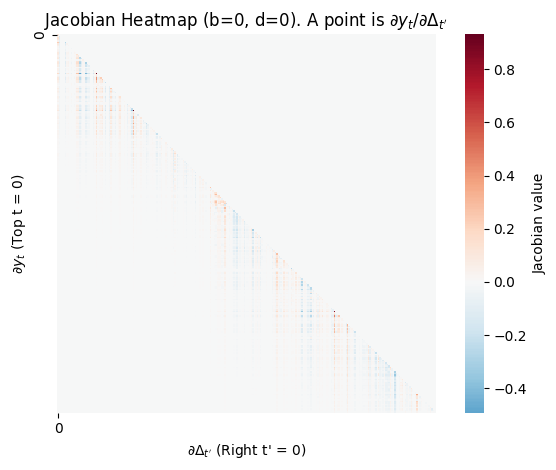

In [ ]:
X_embed = model.model.embedding(X)
X_mamba, _ = model.model.mamba.layers[0].mixer.in_proj(X_embed).chunk(2, dim=-1)

ax = plt.gca()

plot_jacobian_dy_dt(params, X_mamba, b_dim=0, d_dim=0, ax=plt.gca(), log=False)
plt.tight_layout()

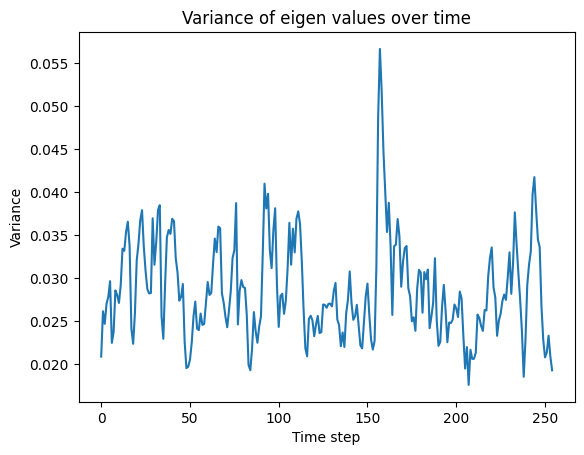

In [37]:
plot_variance(dA, plt.gca(), window=5)

In [144]:
M = dA[2]
window = 50
l = len(M)

reshaped = M.reshape(l, -1)
variances = []

for t in range(l):
    start = t
    end = min(l, t + window)
    window_data = reshaped[start:end, :]
    v = torch.var(window_data, dim=0).mean()
    variances.append(v)

variances = torch.stack(variances).detach().cpu().numpy()

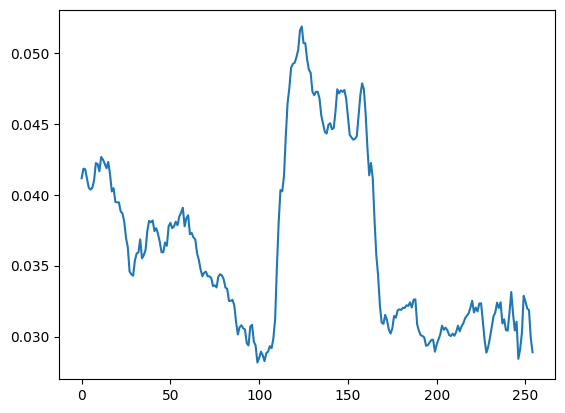

In [145]:
plt.plot(variances)

In [ ]:
from matplotlib.animation import PillowWriter, FuncAnimation
import numpy as np
import matplotlib.pyplot as plt
import torch


def animate_eigen_text(
    X,
    M,
    save_path,
    b_dim,
    d_dim=0,
    step_size=100,
    fps=10,
    tokenizer=None,
    token_ids=None,
    token_position="top_right",
):


    signal = X[b_dim].squeeze().detach().cpu()

    if token_ids is None:
        token_ids = X[b_dim].squeeze()

    if isinstance(token_ids, torch.Tensor):
        token_ids = token_ids.detach().cpu().tolist()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    animated_plot = ax1.scatter([], [], c=[], cmap="viridis", s=40)
    animated_signal, = ax2.plot([], [], lw=2)

    ax1.set_xlim([-1.2, 1.2])
    ax1.set_ylim([-1.2, 1.2])
    ax1.set_aspect("equal")
    ax1.set_title("Eigenvalues / Points in Complex Plane")

    theta = np.linspace(0, 2 * np.pi, 400)
    ax1.plot(np.cos(theta), np.sin(theta), linestyle=":", color="gray")

    signal_np = signal.numpy() if isinstance(signal, torch.Tensor) else np.array(signal)
    ax2.set_xlim([0, len(signal_np)])
    ax2.set_ylim([signal_np.min(), signal_np.max()])
    ax2.set_title("Signal Progression")
    ax2.set_xlabel("Token / Time Step")
    ax2.set_ylabel("Signal Value")

    t = np.arange(len(signal_np))

    position_map = {
        "top_right": (0.98, 0.98, "right", "top"),
        "top_left": (0.02, 0.98, "left", "top"),
        "bottom_right": (0.98, 0.02, "right", "bottom"),
        "bottom_left": (0.02, 0.02, "left", "bottom"),
    }
    x_text, y_text, ha, va = position_map.get(token_position, position_map["top_right"])

    token_text = ax1.text(
        x_text,
        y_text,
        "",
        transform=ax1.transAxes,
        ha=ha,
        va=va,
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    def decode_token(token_id):
        if tokenizer is None:
            return str(token_id)

        try:
            tok = tokenizer.convert_ids_to_tokens(int(token_id))
            if tok is None:
                return str(token_id)

            # Make GPT-style tokens more readable
            tok = tok.replace("Ġ", "␠")   # leading space marker
            tok = tok.replace("Ċ", "\\n") # newline marker
            return tok
        except Exception:
            try:
                return tokenizer.decode([int(token_id)])
            except Exception:
                return str(token_id)

    def update_data(frame):
        time_idx = min(frame * step_size, M.shape[1] - 1)

        points = M[b_dim, time_idx, d_dim, :]
        points_array = np.stack(
            (points.real.detach().cpu().numpy(),
             points.imag.detach().cpu().numpy()),
            axis=-1
        ).reshape(-1, 2)

        animated_plot.set_offsets(points_array)
        animated_plot.set_array(np.arange(len(points_array)))
        ax1.set_title(f"Complex Plane (t = {time_idx})")

        end_idx = min(time_idx, len(signal_np))
        animated_signal.set_data(t[:end_idx], signal_np[:end_idx])

        if time_idx < len(token_ids):
            current_token = decode_token(token_ids[time_idx])
            token_text.set_text(f"token[{time_idx}] = {current_token}")
        else:
            token_text.set_text(f"token[{time_idx}] = <out of range>")

        return animated_plot, animated_signal, token_text

    n_frames = max(1, int(np.ceil(M.shape[1] / step_size)))

    animation = FuncAnimation(
        fig,
        update_data,
        frames=n_frames,
        interval=1000 / fps, 
        repeat=False,
        blit=False,
    )

    animation.save(save_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"Animation saved to {save_path} at {fps} fps!")

In [ ]:
animate_eigen_text(X, dB, b_dim=0, d_dim=1, save_path='analyse/animations/wikitext/animation.gif', step_size=1, token_ids=X[0].cpu(), tokenizer=tok, fps=5)

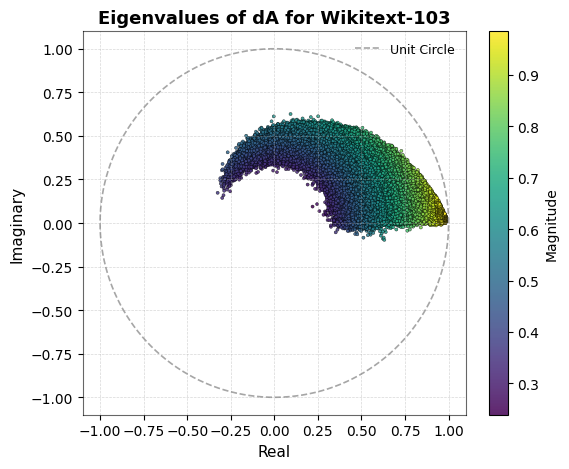

In [14]:
plot_eigen(torch.flatten(dA[0, 0, :, :].cpu()), plt.gca(), s=5, title="Eigenvalues of dA for Wikitext-103")